<a href="https://colab.research.google.com/github/Sudeeppp-Mishra/IPPR-101/blob/main/Lab-Works/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total Connected Components: 82
Largest Component: 18
Area: 18746


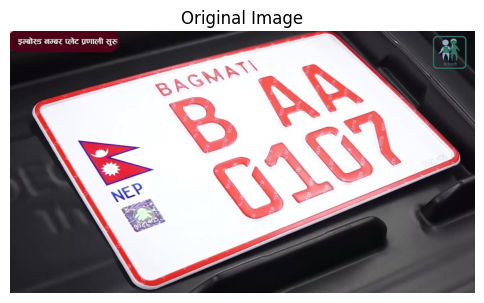

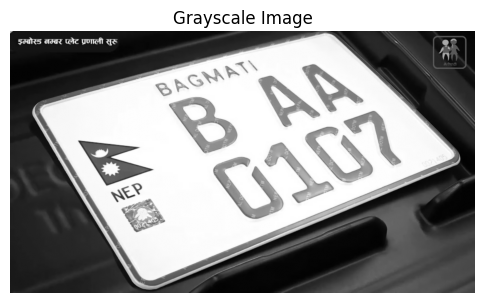

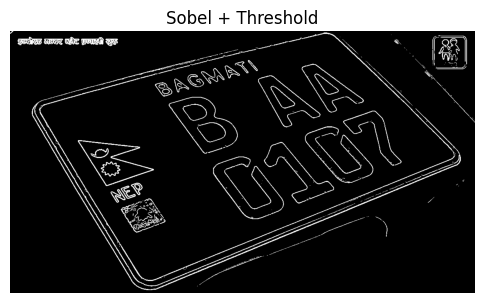

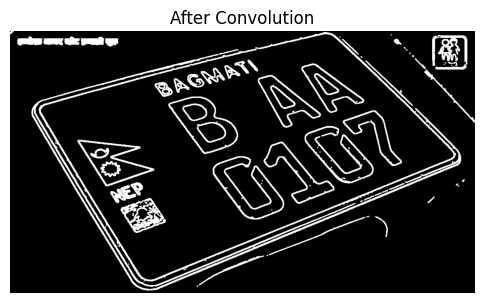

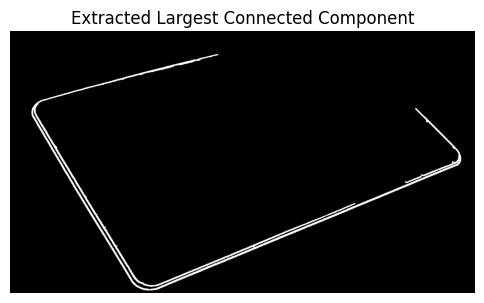

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.measure import label

# ==========================
# Read Image
# ==========================
im = cv2.imread("/content/number_plate.jpg")

if im is None:
    raise FileNotFoundError("Image not found!")

# Convert BGR to RGB (for display)
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Median filtering (3×3)
gray = cv2.medianBlur(gray, 3)

# ==========================
# Sobel Edge Detection
# ==========================
grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Normalize gradient
magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
magnitude = magnitude.astype(np.uint8)

# Otsu Thresholding
_, BW = cv2.threshold(
    magnitude,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# ==========================
# Convolution Mask
# ==========================
mask = np.array([
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,1,1,1,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
], dtype=np.uint8)

# Convolution
B = convolve2d(BW/255.0, mask, mode='same')

# Binary image after convolution
B_binary = (B > 0).astype(np.uint8)

# ==========================
# Connected Components
# ==========================
L = label(B_binary, connectivity=2)

num_components = L.max()
print("Total Connected Components:", num_components)

# ==========================
# Find Largest Component
# ==========================
largest_area = 0
best_component = 0

for i in range(1, num_components + 1):
    area = np.sum(L == i)
    if area > largest_area:
        largest_area = area
        best_component = i

print("Largest Component:", best_component)
print("Area:", largest_area)

# Extract largest component
plate = np.zeros_like(BW)

plate[L == best_component] = 255

# ==========================
# Display Results
# ==========================
plt.figure(figsize=(6,6))
plt.imshow(im_rgb)
plt.title("Original Image")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(BW, cmap='gray')
plt.title("Sobel + Threshold")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(B_binary, cmap='gray')
plt.title("After Convolution")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(plate, cmap='gray')
plt.title("Extracted Largest Connected Component")
plt.axis("off")

plt.show()

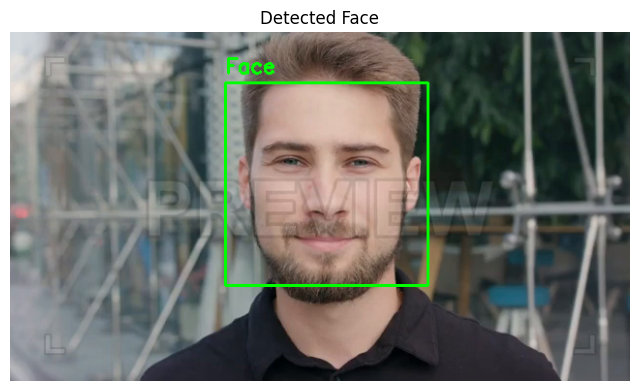

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load Haar Cascade face detector
face_detector = cv2.CascadeClassifier(
cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Open the video file
video = cv2.VideoCapture("video.mp4")

# Read the first frame
ret, frame = video.read()

if not ret:
  print("Error: Could not read the video.")
  exit()

# Convert frame to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_detector.detectMultiScale(
gray,
scaleFactor=1.1,
minNeighbors=5,
minSize=(30, 30)
)

# Draw rectangles around detected faces
for (x, y, w, h) in faces:
  cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
  cv2.putText(frame, "Face", (x, y - 10),
  cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0, 255, 0), 2)

# Convert BGR to RGB for Matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title("Detected Face")
plt.axis("off")
plt.show()

# Release the video
video.release()